### Descriptive Statistics — News Analyst Ratings
Exploratory analysis covering:
1. Headline character length distribution
2. Articles per publisher
3. Publication volume trends over time

In [1]:
import sys
sys.path.insert(0, '.')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from src.eda import (
    load_data,
    clean_data,
    headline_length_stats,
    plot_headline_length_distribution,
    articles_per_publisher,
    plot_articles_per_publisher,
    publication_date_trends,
    plot_publication_trends,
    top_publishing_days,
    top_count_terms,
    top_tfidf_terms,
    plot_top_terms,
    financial_phrase_counts,
    plot_financial_phrases,
    lda_topics,
    plot_lda_topics,
    publishing_hour_distribution,
    plot_publishing_hours,
    extract_publisher_domains,
    plot_publisher_domains,
    publisher_coverage_profile,
)

DATA_PATH = 'data/raw/raw_analyst_ratings.csv'
OUTPUT_DIR = Path('data/outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

In [2]:
df = load_data(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Date range: {df["date"].min()} → {df["date"].max()}')
df.head()

Shape: (1407328, 7)
Columns: ['headline', 'url', 'publisher', 'date', 'stock', 'pub_date', 'pub_hour']
Date range: 2009-02-14 00:00:00+00:00 → 2020-06-11 21:12:35+00:00


,headline,url,publisher,date,stock,pub_date,pub_hour
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54+00:00,A,2020-06-05,10
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20+00:00,A,2020-06-03,10
2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07+00:00,A,2020-05-26,4
3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06+00:00,A,2020-05-22,12
4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59+00:00,A,2020-05-22,11


In [3]:
df, report = clean_data(df)

print("=== Data Cleaning Report ===")
print(f"  Original rows   : {report['original_rows']:,}")
print(f"  Duplicates removed : {report['duplicates_removed']:,}")
print(f"  Missing removed    : {report['missing_removed']:,}")
print(f"  Final rows      : {report['final_rows']:,}")
print("\nRemaining nulls by column:")
for col, n in report['missing_by_column'].items():
    print(f"  {col:<12}: {n:,}")

=== Data Cleaning Report ===
  Original rows   : 1,407,328
  Duplicates removed : 1
  Missing removed    : 0
  Final rows      : 1,407,327

Remaining nulls by column:
  headline    : 0
  url         : 0
  publisher   : 0
  date        : 0
  stock       : 0


## 1. Headline Character Length

In [4]:
stats = headline_length_stats(df)
print('Headline length statistics:')
print(stats.round(2).to_string())

Headline length statistics:
count     1407327.00
mean           73.12
std            40.74
min             3.00
25%            47.00
50%            64.00
75%            87.00
max           512.00
median         64.00


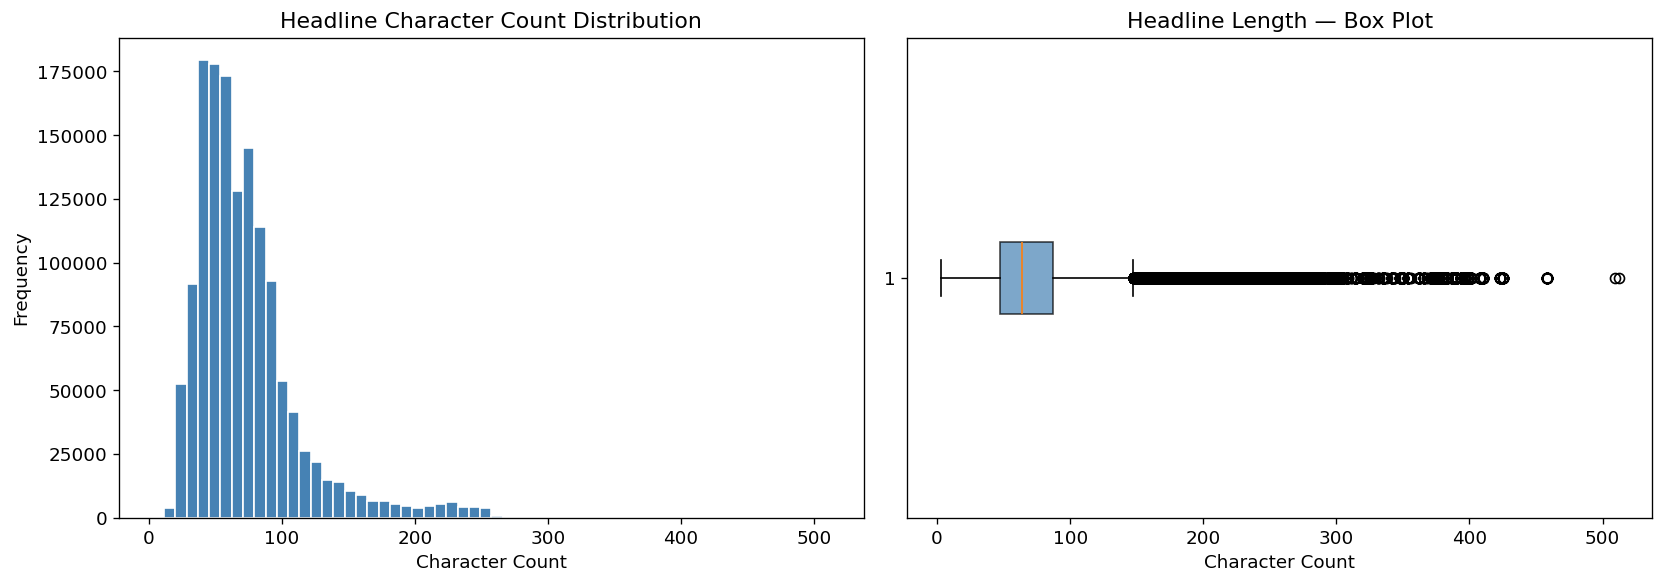

In [5]:
fig = plot_headline_length_distribution(df, save_path=str(OUTPUT_DIR / 'headline_length_dist.png'))
plt.show()

## 2. Articles per Publisher

In [6]:
publisher_counts = articles_per_publisher(df, top_n=20)
print(f'Total unique publishers: {df["publisher"].nunique()}')
print('\nTop 20 publishers:')
print(publisher_counts.to_string())

Total unique publishers: 1034

Top 20 publishers:
publisher
Paul Quintaro        228373
Lisa Levin           186978
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Allie Wickman         18317
Shanthi Rexaline      16640
Craig Jones           16221
Wayne Duggan          12897
Nelson Hem            12590


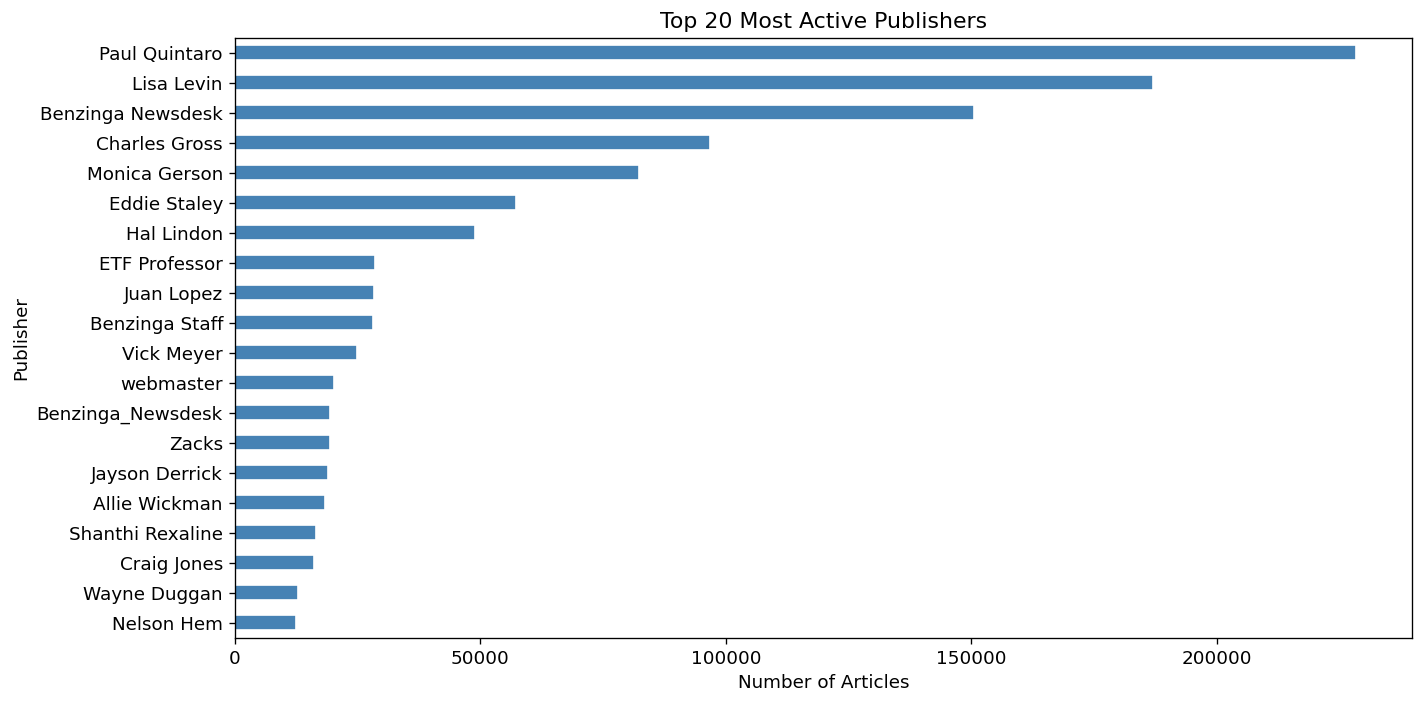

In [7]:
fig = plot_articles_per_publisher(df, top_n=20, save_path=str(OUTPUT_DIR / 'articles_per_publisher.png'))
plt.show()

## 3. Publication Volume Trends Over Time

In [8]:
weekly = publication_date_trends(df, freq='W')
print(f'Weekly trend — {len(weekly)} weeks')
print(f'Peak week: {weekly.idxmax().date()} ({weekly.max()} articles)')
print(f'Average per week: {weekly.mean():.0f}')

Weekly trend — 592 weeks
Peak week: 2020-03-15 (7587 articles)
Average per week: 2377


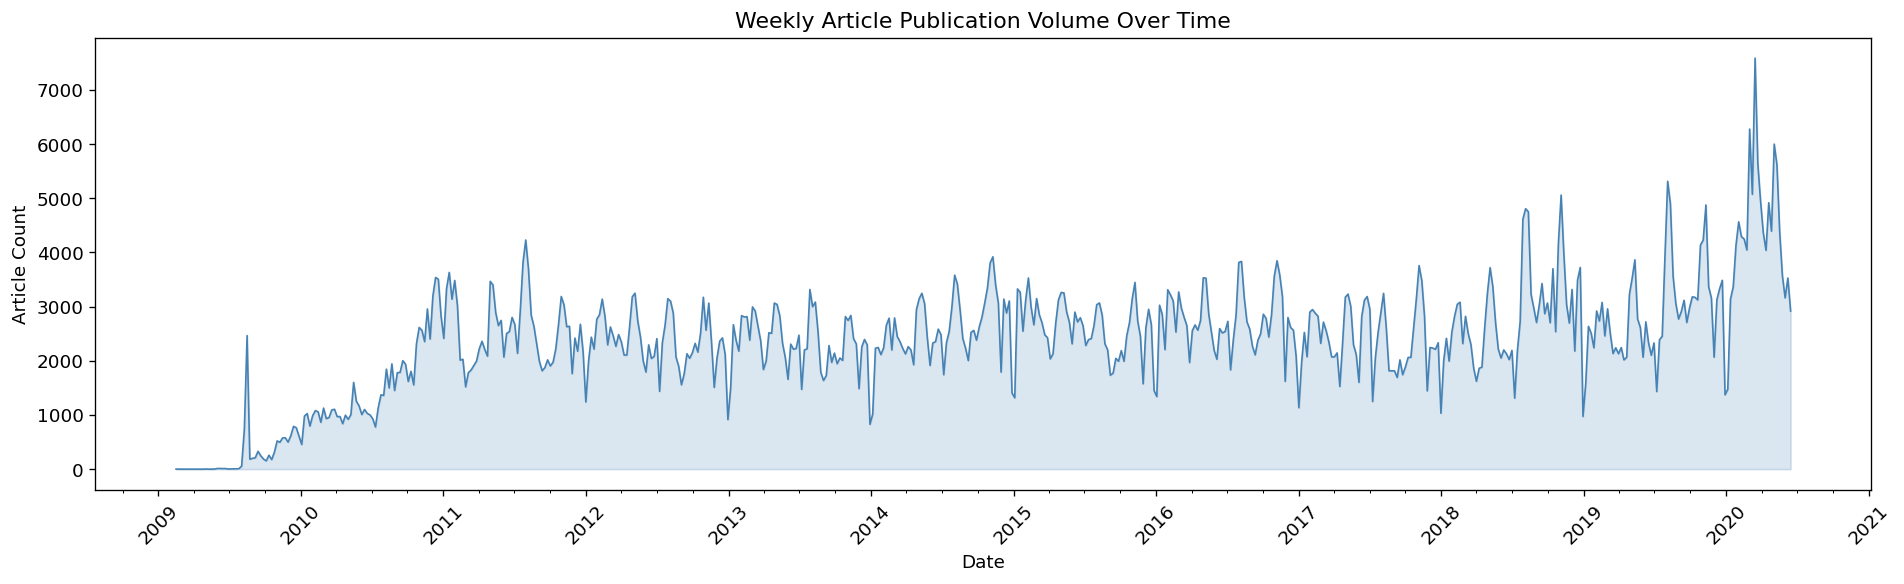

In [9]:
fig = plot_publication_trends(df, freq='W', save_path=str(OUTPUT_DIR / 'publication_trends_weekly.png'))
plt.show()

### Top 10 Highest-Volume Days

In [11]:
top_days = top_publishing_days(df, top_n=10)
print('Days with the most published articles:')
print(top_days.to_string(index=False))

Days with the most published articles:
      date  article_count
2020-03-12           2739
2020-02-28           1620
2020-03-19           1594
2020-02-27           1567
2020-03-06           1428
2020-05-07           1396
2020-03-23           1390
2020-04-29           1389
2020-03-11           1384
2020-04-30           1327


### 1. Top keywords by raw frequency (unigrams)

In [13]:
unigrams = top_count_terms(df, top_n=20, ngram_range=(1, 1))
print("Top 20 keywords (count):")
print(unigrams.to_string())

Top 20 keywords (count):
vs            162099
stocks        161776
est           140604
eps           128897
market        120558
shares        114313
reports       108710
update         91723
earnings       87399
sales          79645
benzinga       74516
pt             73068
week           69572
announces      66591
price          64407
buy            64371
mid            62263
downgrades     61959
trading        61182
raises         57802


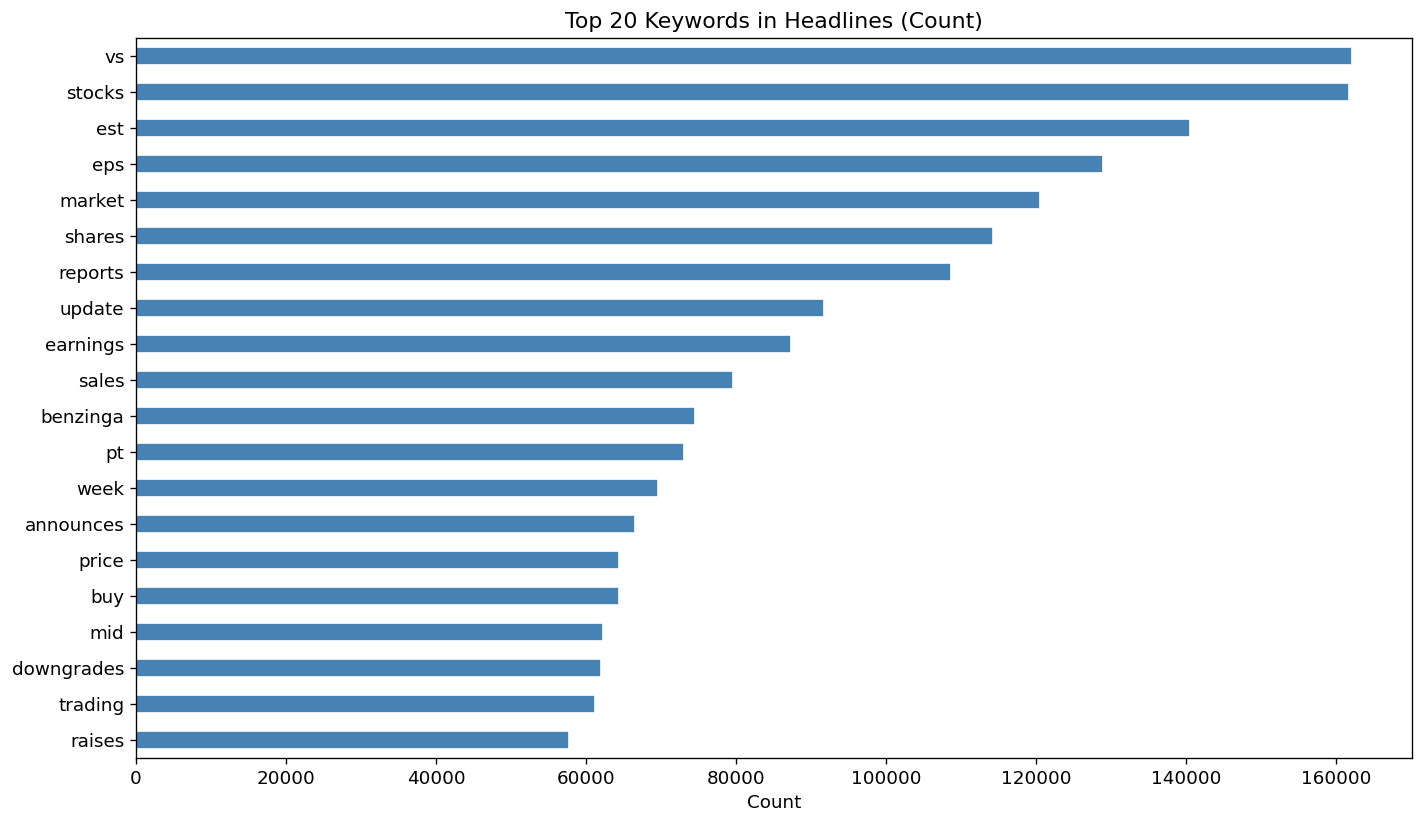

In [14]:
fig = plot_top_terms(unigrams, title="Top 20 Keywords in Headlines (Count)",
                     save_path=str(OUTPUT_DIR / "top_keywords.png"))
plt.show()

## 4. NLP — Keywords, Phrases & Topic Modeling

### 4. Financial phrase frequency

Financial phrase occurrences in headlines:
price target          47634
dividend              21572
acquisition            8911
buy rating             6024
merger                 5621
downgraded             3263
earnings beat          3155
upgraded               3093
clinical trial         2485
hold rating            1561
earnings miss          1419
interest rate          1147
share repurchase       1140
52 week high           1133
federal reserve        1049
special dividend        739
rate cut                593
rate hike               500
quarterly earnings      496
revenue growth          459
sell rating             423
stock buyback           234
short squeeze           213
market cap              211
guidance cut            203
insider buying          114
earnings per share      107
revenue beat            102
drug approval            59
52 week low              43
guidance raised          26


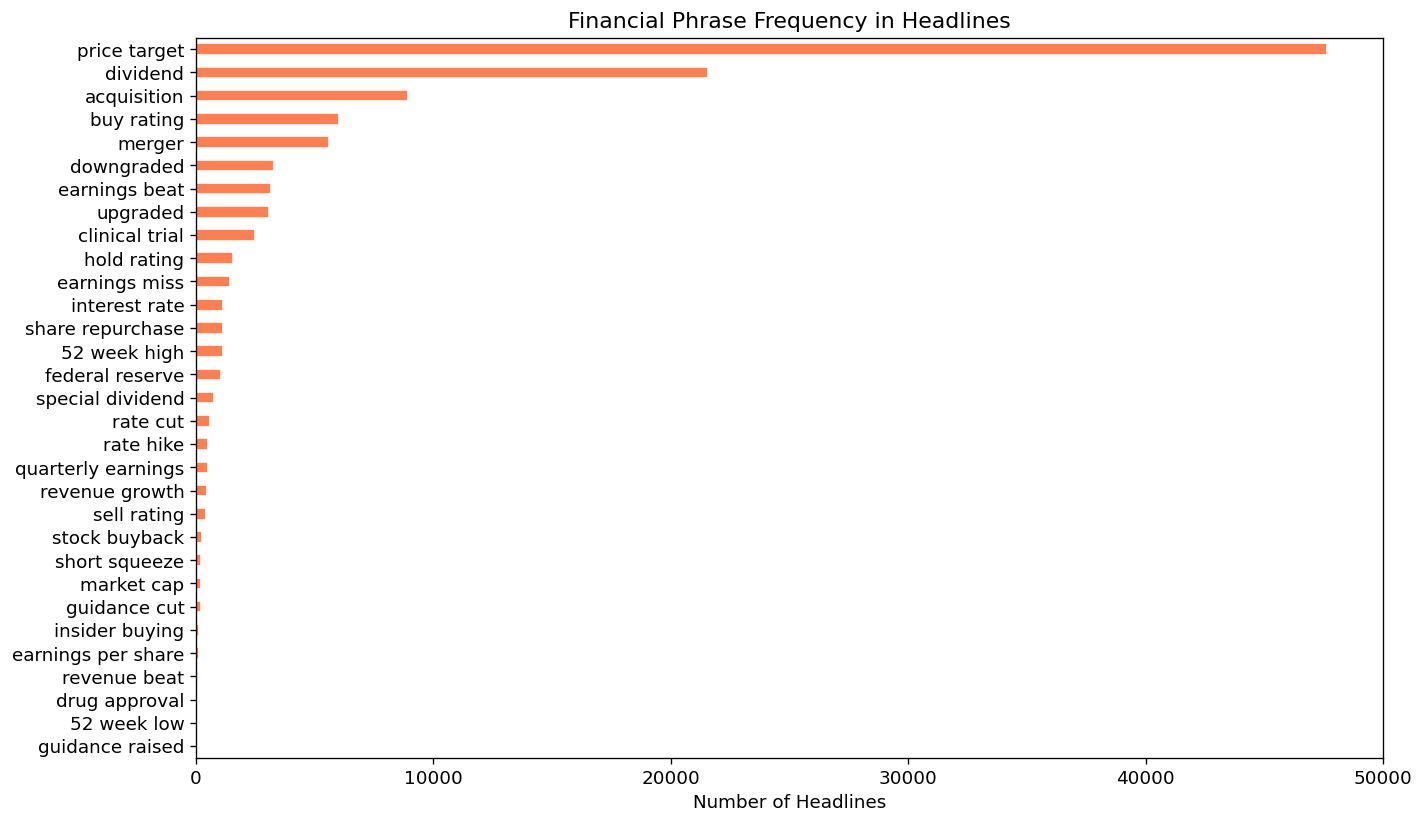

In [17]:
phrase_counts = financial_phrase_counts(df)
print("Financial phrase occurrences in headlines:")
print(phrase_counts[phrase_counts > 0].to_string())

fig = plot_financial_phrases(df, save_path=str(OUTPUT_DIR / "financial_phrases.png"))
plt.show()

### 5. LDA topic modeling (stratified sample) 

LDA Topics (stratified sample across all months):
  Topic 1: vs, est, eps, reports, sales, q4, sees, q1, q2, estimate
  Topic 2: pt, buy, raises, maintains, 00, price, target, downgrades, initiates, bank
  Topic 3: stocks, week, 52, new, highs, set, hit, stock, data, ahead
  Topic 4: earnings, benzinga, scheduled, watch, etfs, upgrades, downgrades, 2019, 2010, news
  Topic 5: stocks, market, session, moving, mid, pre, benzinga, day, biggest, morning
  Topic 6: announces, share, shares, dividend, reports, volume, stock, offering, energy, agreement
  Topic 7: shares, update, market, trading, higher, companies, lower, mid, oil, following
  Topic 8: says, ceo, money, new, stake, update, shows, deal, cramer, time


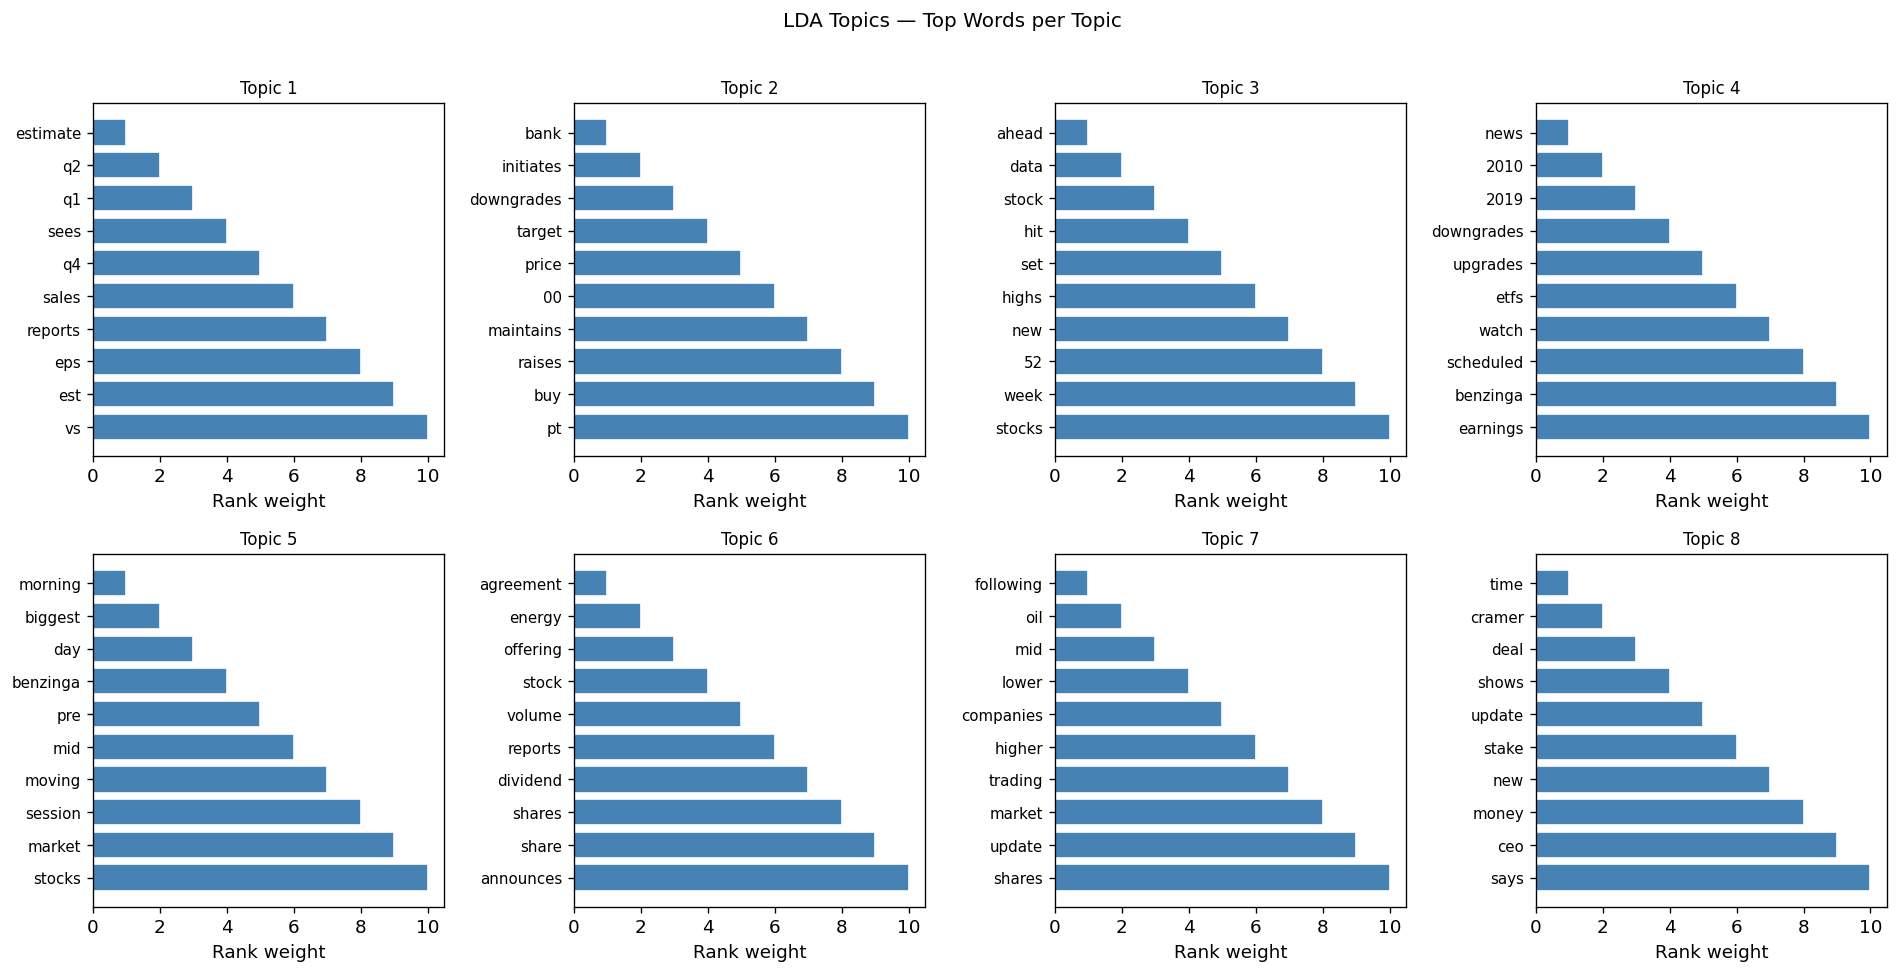

In [18]:
topics = lda_topics(df, n_topics=8, top_words=10, sample_n=100_000)
print("LDA Topics (stratified sample across all months):")
for t in topics:
    print(f"  Topic {t['topic']}: {', '.join(t['words'])}")

fig = plot_lda_topics(topics, save_path=str(OUTPUT_DIR / "lda_topics.png"))
plt.show()

## 5. Time Series — Publication Volume & Publishing Hours

In [ ]:
hour_counts = publishing_hour_distribution(df)
peak_hour = hour_counts.idxmax()
print(f"Peak publishing hour (local time): {peak_hour}:00  ({hour_counts[peak_hour]:,} articles)")
print(f"Quietest hour (local time): {hour_counts.idxmin()}:00  ({hour_counts.min():,} articles)")

fig = plot_publishing_hours(df, save_path=str(OUTPUT_DIR / "publishing_hours.png"))
plt.show()

## 6. Publisher Analysis

In [ ]:
print(f"Total unique publishers: {df['publisher'].nunique()}")
email_pubs = df[df["publisher"].str.contains("@", na=False)]
print(f"Email-format publishers: {email_pubs['publisher'].nunique()}")
print(f"Name-format publishers:  {df['publisher'].nunique() - email_pubs['publisher'].nunique()}")

profile = publisher_coverage_profile(df, top_n=10)
print("\nPublisher coverage profiles:")
print(profile.to_string(index=False))

In [ ]:
print(f"Total unique publishers: {df['publisher'].nunique()}")
email_pubs = df[df["publisher"].str.contains("@", na=False)]
print(f"Email-format publishers: {email_pubs['publisher'].nunique()}")
print(f"Name-format publishers:  {df['publisher'].nunique() - email_pubs['publisher'].nunique()}")